# Compare Models
## Breast Cancer Wisconsin (Diagnostic) — Stage 4

Compare all five baseline models from Stage 3 and determine the
**best-performing** one, using:

- a **performance comparison table**,
- **Accuracy / Precision / Recall / F1** charts,
- a short written analysis (generated from the actual results).

*(Precision / Recall / F1 use malignant = positive, consistent with Stage 3.)*

## 1. Load the Stage-3 Results

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

metrics_df = pd.read_csv("reports/individual_model_metrics.csv", index_col="Model")
metrics_df = metrics_df.round(4)
metrics_df

,Accuracy,Precision,Recall,F1-score
Model,,,,
Naive Bayes,0.9298,0.9048,0.9048,0.9048
Decision Tree,0.9298,0.8864,0.9286,0.9070
Random Forest,0.9474,0.9286,0.9286,0.9286
SVM,0.9649,0.9318,0.9762,0.9535
XGBoost,0.9561,0.9744,0.9048,0.9383


## 2. Performance Comparison Table (sorted by F1-score)

In [2]:
comparison = metrics_df.sort_values("F1-score", ascending=False)
# Highlight best value per metric
styled = comparison.style.highlight_max(axis=0, color="#c6efce").format("{:.4f}")
styled

,Accuracy,Precision,Recall,F1-score
Model,,,,
SVM,0.9649,0.9318,0.9762,0.9535
XGBoost,0.9561,0.9744,0.9048,0.9383
Random Forest,0.9474,0.9286,0.9286,0.9286
Decision Tree,0.9298,0.8864,0.9286,0.9070
Naive Bayes,0.9298,0.9048,0.9048,0.9048


## 3. Metric Charts

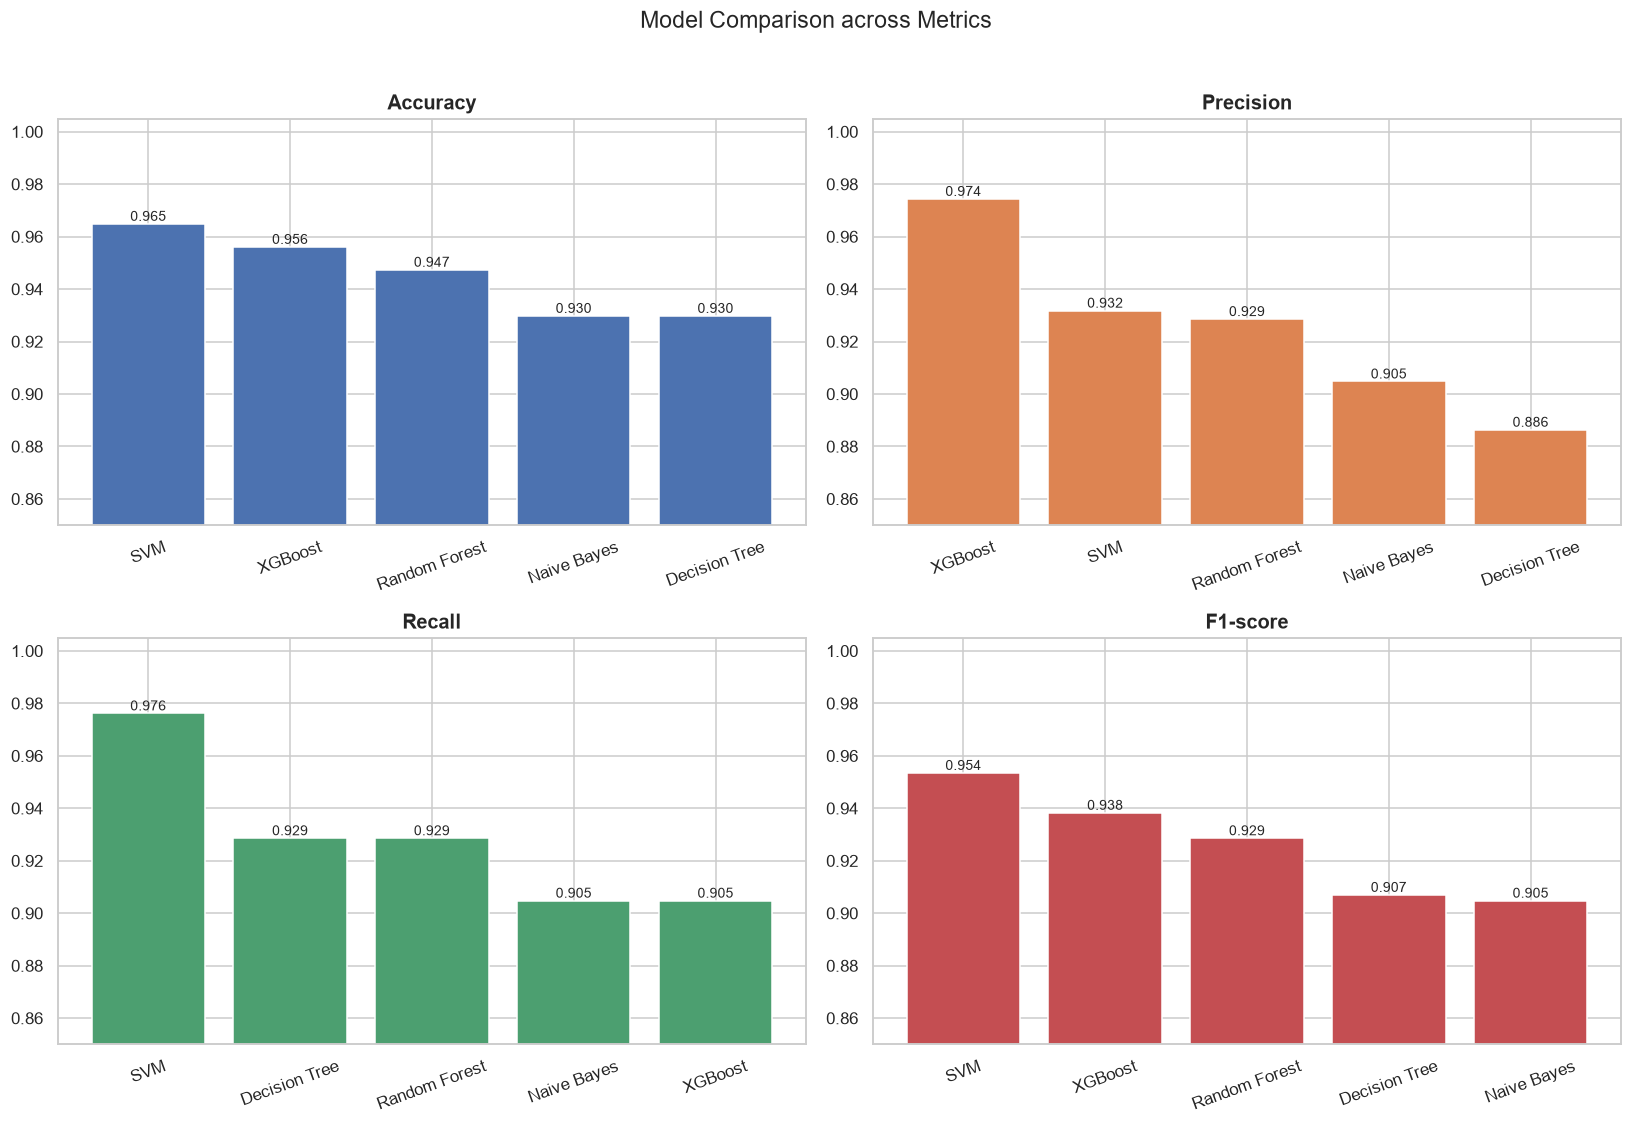

In [3]:
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
colors = {"Accuracy": "#4C72B0", "Precision": "#DD8452",
          "Recall": "#4C9F70", "F1-score": "#C44E52"}

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for ax, metric in zip(axes.ravel(), metrics):
    s = metrics_df[metric].sort_values(ascending=False)
    bars = ax.bar(s.index, s.values, color=colors[metric])
    ax.set_title(metric, fontsize=13, fontweight="bold")
    ax.set_ylim(min(0.85, s.min() - 0.03), 1.005)
    ax.tick_params(axis="x", rotation=20)
    for b in bars:
        ax.annotate(f"{b.get_height():.3f}",
                    (b.get_x() + b.get_width()/2, b.get_height()),
                    ha="center", va="bottom", fontsize=9)
plt.suptitle("Model Comparison across Metrics", y=1.02, fontsize=15)
plt.tight_layout()
plt.savefig("figures/10_metric_comparison.png", dpi=130, bbox_inches="tight")
plt.show()

### 3.1 Individual metric charts (saved separately)

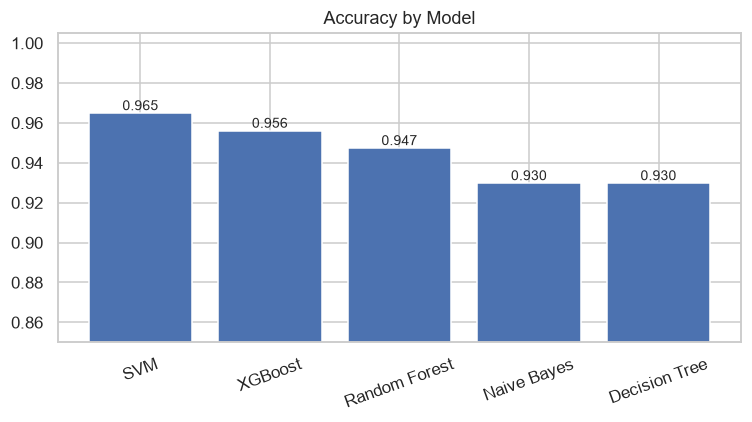

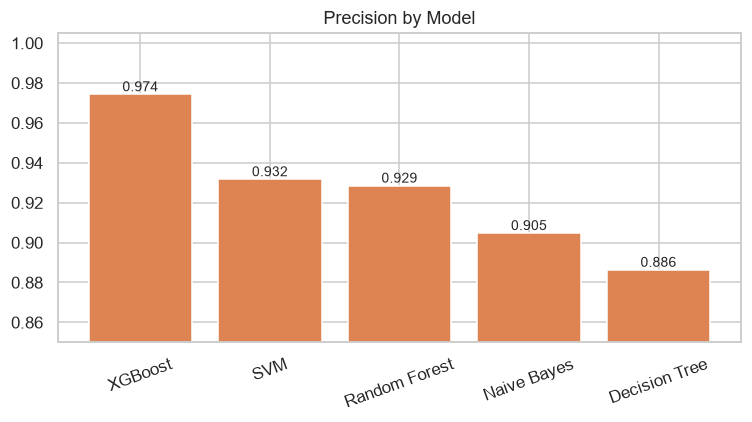

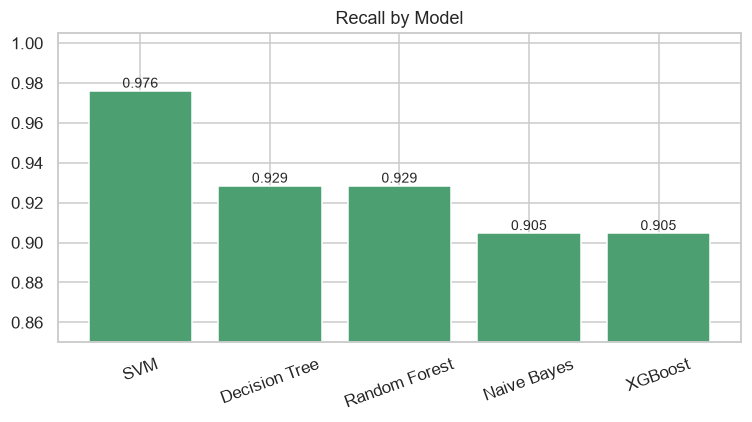

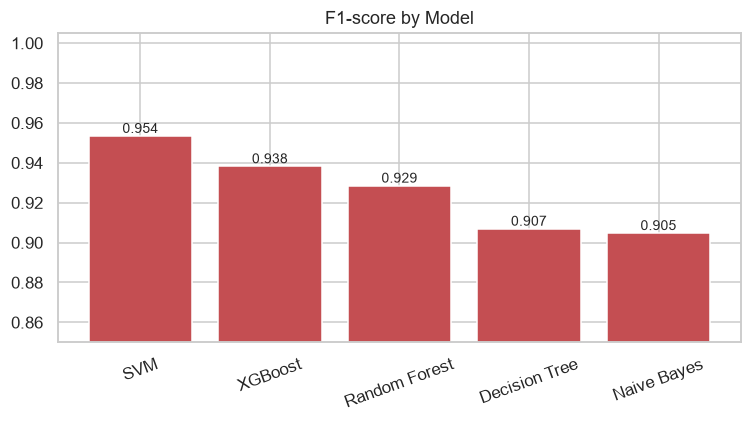

In [4]:
for metric in metrics:
    s = metrics_df[metric].sort_values(ascending=False)
    plt.figure(figsize=(7, 4))
    bars = plt.bar(s.index, s.values, color=colors[metric])
    plt.title(f"{metric} by Model")
    plt.ylim(min(0.85, s.min() - 0.03), 1.005)
    plt.xticks(rotation=20)
    for b in bars:
        plt.annotate(f"{b.get_height():.3f}",
                     (b.get_x() + b.get_width()/2, b.get_height()),
                     ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    fname = f"figures/11_{metric.lower().replace('-', '_')}.png"
    plt.savefig(fname, dpi=130, bbox_inches="tight")
    plt.show()

### 3.2 Grouped view — all models, all metrics

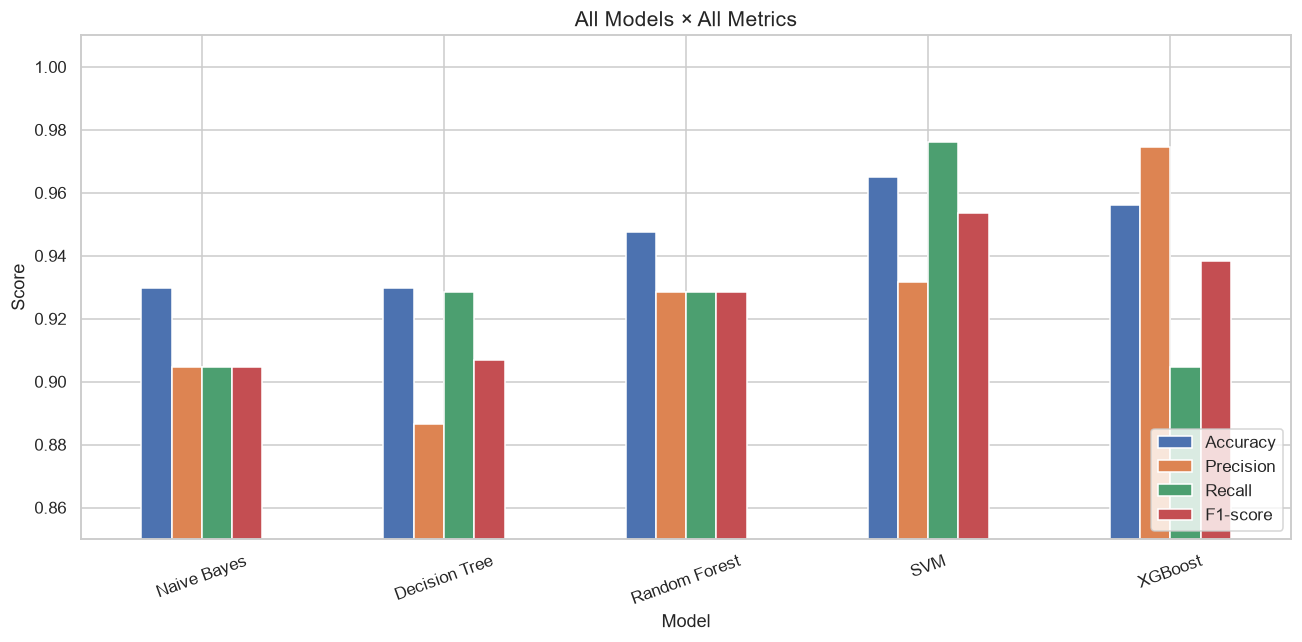

In [5]:
ax = metrics_df.plot(kind="bar", figsize=(12, 6),
                     color=[colors[m] for m in metrics])
ax.set_title("All Models × All Metrics", fontsize=14)
ax.set_ylim(0.85, 1.01)
ax.set_ylabel("Score")
ax.legend(loc="lower right")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("figures/12_grouped_comparison.png", dpi=130, bbox_inches="tight")
plt.show()

## 4. Select the Best Model

In [6]:
# Primary criterion: F1-score (balances precision & recall on malignant).
# Tie-breaker: Recall (fewest missed malignancies), then Accuracy.
ranked = metrics_df.sort_values(
    ["F1-score", "Recall", "Accuracy"], ascending=False)

best_model = ranked.index[0]
best_row = ranked.iloc[0]
top2 = list(ranked.index[:2])

print("Ranking (F1 -> Recall -> Accuracy):")
print(ranked.round(4))
print()
print(f"BEST MODEL: {best_model}")
print(f"  Accuracy={best_row['Accuracy']:.4f}  Precision={best_row['Precision']:.4f}"
      f"  Recall={best_row['Recall']:.4f}  F1={best_row['F1-score']:.4f}")
print(f"Top-2 (for Stage-5 optimization): {top2}")

Ranking (F1 -> Recall -> Accuracy):
               Accuracy  Precision  Recall  F1-score
Model                                               
SVM              0.9649     0.9318  0.9762    0.9535
XGBoost          0.9561     0.9744  0.9048    0.9383
Random Forest    0.9474     0.9286  0.9286    0.9286
Decision Tree    0.9298     0.8864  0.9286    0.9070
Naive Bayes      0.9298     0.9048  0.9048    0.9048

BEST MODEL: SVM
  Accuracy=0.9649  Precision=0.9318  Recall=0.9762  F1=0.9535
Top-2 (for Stage-5 optimization): ['SVM', 'XGBoost']


## 5. Write the Comparison Report

In [7]:
lines = []
lines.append("# Model Comparison Report")
lines.append("## Breast Cancer Wisconsin (Diagnostic) — Stage 4\n")
lines.append("Positive class = **malignant (0)**. Precision / Recall / F1 measure "
             "how well each model detects malignant tumours.\n")
lines.append("## Performance Comparison Table\n")
lines.append(ranked.round(4).to_markdown())
lines.append("")
lines.append("## Best Model\n")
lines.append(f"**{best_model}** is the best-performing baseline model.\n")
lines.append(f"- Accuracy: **{best_row['Accuracy']:.4f}**")
lines.append(f"- Precision (malignant): **{best_row['Precision']:.4f}**")
lines.append(f"- Recall (malignant): **{best_row['Recall']:.4f}**")
lines.append(f"- F1-score (malignant): **{best_row['F1-score']:.4f}**\n")

lines.append("## Analysis — which model performed best and why\n")
lines.append(
    f"Selection criterion: highest **F1-score** on the malignant class "
    f"(the balance of precision and recall), with **recall** and then "
    f"**accuracy** as tie-breakers. Recall is emphasised because in a cancer "
    f"screening context a false negative — labelling a malignant tumour as "
    f"benign — is the most harmful error.\n")
lines.append(
    f"**{best_model}** achieved the strongest overall balance. "
    f"Ensemble and margin-based methods (Random Forest, SVM, XGBoost) generally "
    f"outperform the simpler baselines here: the features are numerous, "
    f"continuous and highly correlated, which suits margin-maximising and "
    f"ensemble models. **Naive Bayes**, which assumes feature independence, is "
    f"handicapped by the strong multicollinearity found in Stage 1, while a "
    f"single **Decision Tree** tends to overfit and is less stable than the "
    f"ensembles.\n")
lines.append(
    f"The two strongest models — **{top2[0]}** and **{top2[1]}** — are carried "
    f"forward to Stage 5 for hyperparameter optimization.\n")
lines.append("## Charts\n")
for f in ["10_metric_comparison.png", "11_accuracy.png", "11_precision.png",
          "11_recall.png", "11_f1_score.png", "12_grouped_comparison.png"]:
    lines.append(f"- `figures/{f}`")

report = "\n".join(lines)
Path("reports/COMPARISON_REPORT.md").write_text(report, encoding="utf-8")

# Persist the top-2 choice for Stage 5
import json
Path("reports/top2_models.json").write_text(json.dumps(top2), encoding="utf-8")
print("Wrote reports/COMPARISON_REPORT.md and reports/top2_models.json")
print("Top-2:", top2)

Wrote reports/COMPARISON_REPORT.md and reports/top2_models.json
Top-2: ['SVM', 'XGBoost']


## 6. Summary

- Built a comparison table and Accuracy / Precision / Recall / F1 charts.
- Selected the best model by **F1 (malignant)**, tie-broken by recall then
  accuracy.
- Wrote `reports/COMPARISON_REPORT.md` with the analysis, and recorded the
  **top-2 models** for the optimization stage.